In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

c:\Users\LOQ\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1,  noise=0.35, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [3]:
X.shape

(500, 2)

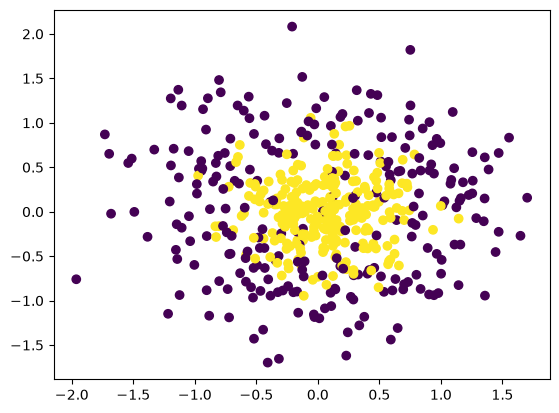

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=y)

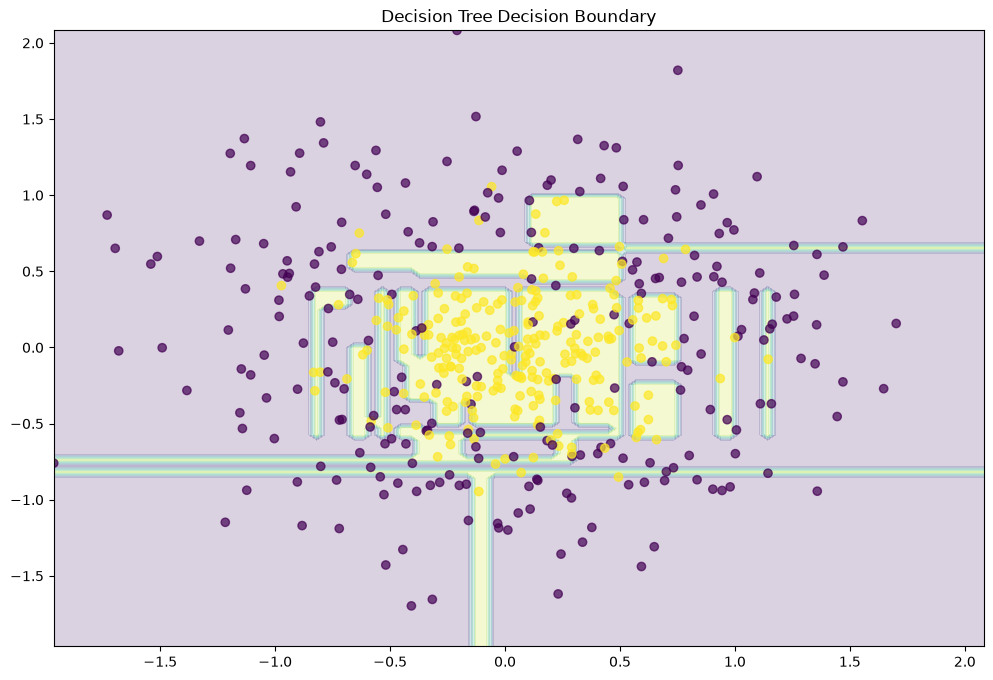

In [6]:
# Import the Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree model
# random_state ensures the results are the same every time you run the code
dtree = DecisionTreeClassifier(random_state=42)

# Train the model using the training data
dtree.fit(X_train, y_train)

# Create a figure for plotting
plt.figure(figsize=(12, 8))

# Generate 100 evenly spaced values between the minimum and maximum value of X
# These values will be used to create a grid over the feature space
x_range = np.linspace(X.min(), X.max(), 100)

# Create a meshgrid (2D grid of points)
# xx1 contains x-coordinates and xx2 contains y-coordinates
xx1, xx2 = np.meshgrid(x_range, x_range)

# Predict the class for every point in the meshgrid
# ravel() converts the 2D arrays into 1D arrays
# np.c_ combines them into (x, y) coordinate pairs
y_hat = dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])

# Convert predictions back to the shape of the meshgrid
# This is required for contour plotting
y_hat = y_hat.reshape(xx1.shape)

# Plot the decision regions
# Different colors represent different predicted classes
plt.contourf(xx1, xx2, y_hat, alpha=0.2)

# Plot the original data points
# c=y colors the points according to their actual class labels
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7)

# Add a title to the plot
plt.title("Decision Tree Decision Boundary")

# Display the plot
plt.show()

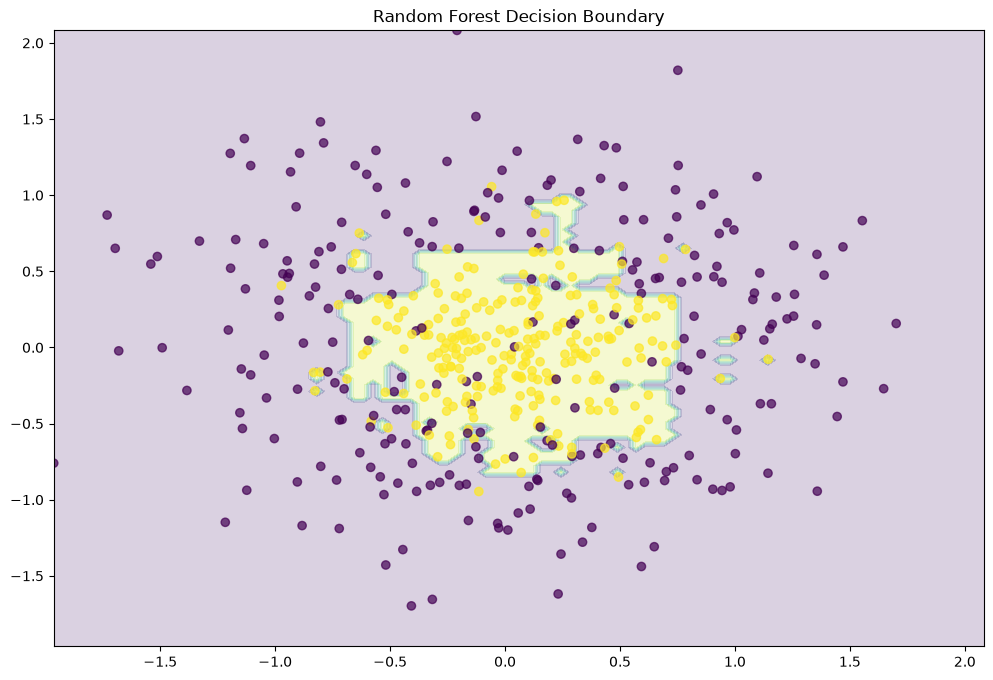

In [7]:
# Import the Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest model
# n_estimators=500 means the model will build 500 decision trees
# random_state ensures reproducible results
rf = RandomForestClassifier(n_estimators=500, random_state=42)

# Train the Random Forest model on the training data
rf.fit(X_train, y_train)

# Create a figure for plotting
plt.figure(figsize=(12, 8))

# Generate 100 evenly spaced values between the minimum and maximum value of X
# These values will be used to create the grid for visualization
x_range = np.linspace(X.min(), X.max(), 100)

# Create a 2D meshgrid using the generated values
# xx1 stores x-coordinates and xx2 stores y-coordinates
xx1, xx2 = np.meshgrid(x_range, x_range)

# Predict the class for every point in the meshgrid
# ravel() converts the 2D arrays into 1D arrays
# np.c_ combines them into (x, y) coordinate pairs
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])

# Reshape the predictions back to the meshgrid shape
# Required for contour plotting
y_hat = y_hat.reshape(xx1.shape)

# Plot the decision regions predicted by the Random Forest
# Each color represents a different predicted class
plt.contourf(xx1, xx2, y_hat, alpha=0.2)

# Plot the original data points
# c=y colors the points according to their true class labels
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7)

# Add a title to the plot
plt.title("Random Forest Decision Boundary")

# Display the plot
plt.show()

In [10]:
n_train = 150
n_test = 1000
noise = 0.1

# Generate data
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()

    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X - 2) ** 2) + np.random.normal(0, noise, n_samples)

    X = X.reshape((n_samples, 1))

    return X, y

X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)

(-5.0, 5.0)

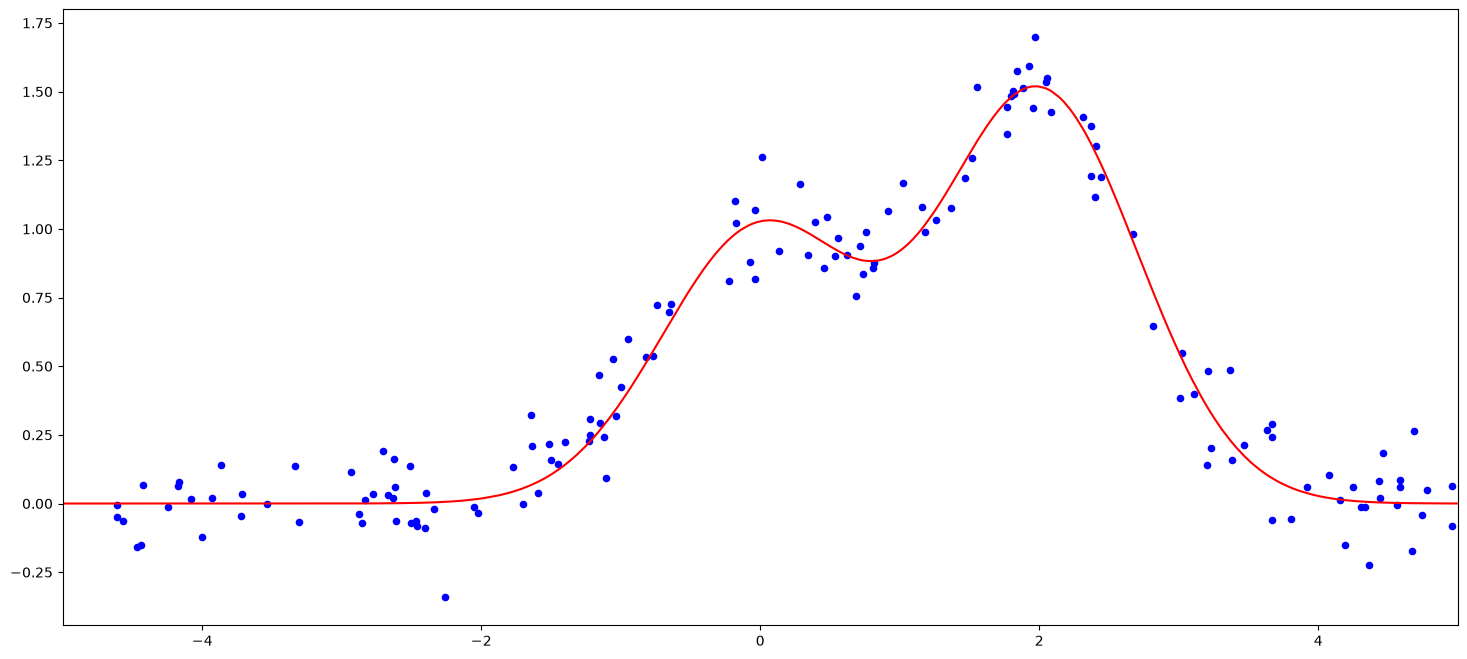

In [11]:
plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.xlim([-5,5])

Text(0.5, 1.0, 'Decision Tree, MSE = 22.70')

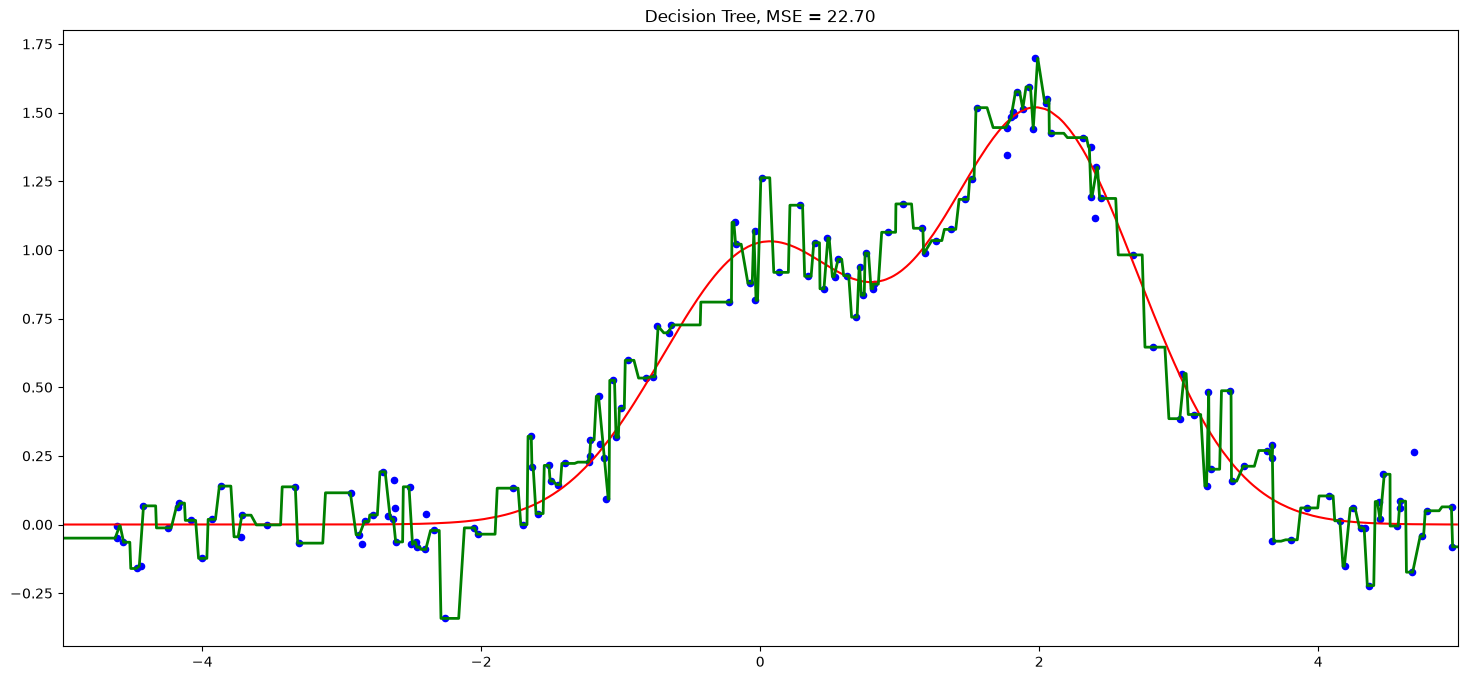

In [12]:
# One Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

dtree = DecisionTreeRegressor().fit(X_train, y_train)
d_predict = dtree.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, d_predict, "g", lw=2)
plt.xlim([-5,5])
plt.title("Decision Tree, MSE = %.2f" % np.sum((y_test - d_predict) ** 2))


Text(0.5, 1.0, 'Random Forest, MSE = 15.73')

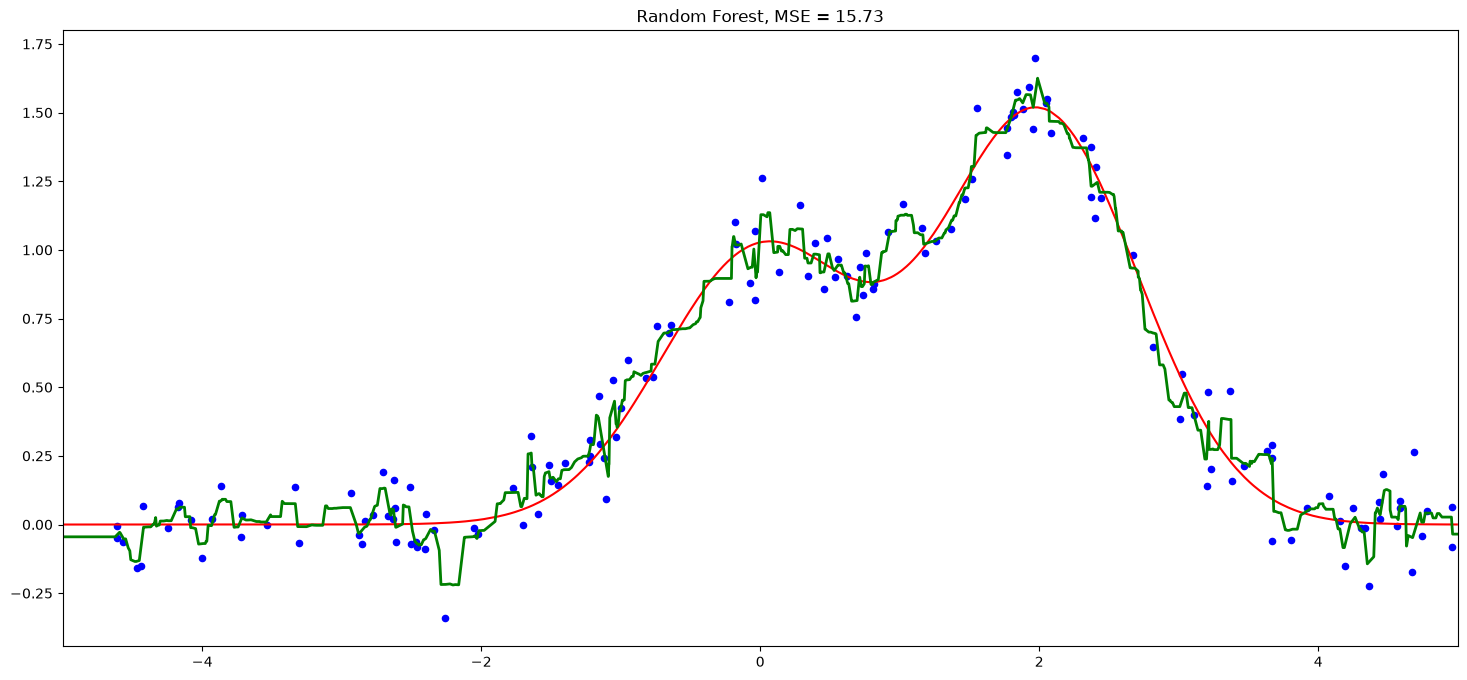

In [13]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(n_estimators=1000).fit(X_train, y_train)
rf_predict = rfr.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, rf_predict, "g", lw=2)
plt.xlim([-5,5])
plt.title("Random Forest, MSE = %.2f" % np.sum((y_test - rf_predict) ** 2))